# Spikes detection



## `find_peaks`

I build on the ideas developed by David [spikesandbursts](https://spikesandbursts.wordpress.com/about/):

> "I have utilized the function FindPeaks to analyze postsynaptic events (see [post](https://spikesandbursts.wordpress.com/2022/07/03/patch-clamp-data-analysis-in-python-postsynaptic-currents-and-potentials/)), and here I show you a simplified version to detect action potentials. For a more detailed analysis of action potentials, I recommend using the packages IPFX or EFEL (tutorials [here](https://spikesandbursts.wordpress.com/2022/05/03/patch-clamp-analysis-python-action-potentials/)). If you have already done the spike analysis, skip this part."

See the function [`scipy.signal.find_peaks`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html)



We import a few libraries:

In [1]:
import numpy as np
import pandas as pd
 
import pyabf
 
import scipy
from scipy import signal
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.stats import skew, kurtosis
 
import matplotlib.pyplot as plt

In [2]:
data_to_explore = []
data_to_explore.append(("lhb_bursting/cell21basal.abf",   5))
data_to_explore.append(("lhb_bursting/cell89basal.abf",  15))
data_to_explore.append(("lhb_bursting/cell91basal.abf",   4))
data_to_explore.append(("lhb_bursting/cell98basal.abf",   9))
data_to_explore.append(("lhb_bursting/cell104basal.abf", 10))
data_to_explore.append(("lhb_bursting/cell105basal.abf",  7))
data_to_explore.append(("lhb_bursting/cell107basal.abf",  0))
data_to_explore.append(("lhb_bursting/cell209basal.abf",  4))

We focus on specific cell, the cell # 89, and we ignore the sweep number for the moment:

In [3]:
file_path = data_to_explore[1][0]
print('path to the abf file : ',file_path)

path to the abf file :  lhb_bursting/cell89basal.abf


## Python libraries

## Load the data

In [4]:
# ABF files
data = file_path
abf = pyabf.ABF(data)
print(abf)

ABF (v2.6) with 1 channel (pA), sampled at 10.0 kHz, containing 30 sweeps, having no tags, with a total length of 11.11 minutes, recorded without a protocol file.


## Pre-process the signal: filtering

"I did not use it for this tutorial, but here is an example of how to filter the signal. More details can be found in this [post](https://spikesandbursts.wordpress.com/2022/07/03/patch-clamp-data-analysis-in-python-postsynaptic-currents-and-potentials/#preprocessing-filtering)."

In [5]:
# Sampling rate
fs = int(abf.dataPointsPerMs * 1000)
 
# Lowpass Bessel filter
b_lowpass, a_lowpass = signal.bessel(4,     # Order of the filter
                                     2000,  # Cutoff frequency
                                     'low', # Type of filter
                                     analog=False,  # Analog or digital filter
                                     norm='phase',  # Critical frequency normalization
                                     fs=fs)  # fs: sampling frequency
 
signal_filtered = signal.filtfilt(b_lowpass, a_lowpass, abf.sweepY)

## Action potentials detection: FindPeaks

"I have utilized the function FindPeaks to analyze postsynaptic events (see [post](https://spikesandbursts.wordpress.com/2022/07/03/patch-clamp-data-analysis-in-python-postsynaptic-currents-and-potentials/)), and here I show you a simplified version to detect action potentials. For a more detailed analysis of action potentials, I recommend using the packages IPFX or EFEL (tutorials [here](https://spikesandbursts.wordpress.com/2022/05/03/patch-clamp-analysis-python-action-potentials/)). If you have already done the spike analysis, skip this part."

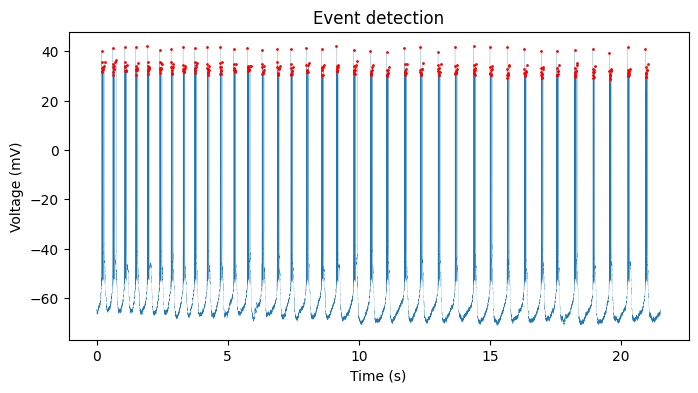

,spike,spike_index,spike_time,inst_freq,isi_s,width,rise_half_ms,decay_half_ms,spike_peak,spike_amplitude
0,1,1933,0.1933,inf,0.0000,0.567354,0.203017,0.364337,40.091000,105.951000
1,2,1985,0.1985,192.307692,0.0052,0.576342,0.178124,0.398218,35.776001,92.254002
2,3,2041,0.2041,178.571429,0.0056,0.582079,0.170146,0.411933,33.273998,86.373997
3,4,2105,0.2105,156.250000,0.0064,0.616574,0.239908,0.376665,32.084999,85.059998
4,5,2177,0.2177,138.888889,0.0072,0.636234,0.183315,0.452919,31.554001,83.778999
...,...,...,...,...,...,...,...,...,...,...
352,353,209610,20.9610,138.888889,0.0072,0.646102,0.235399,0.410703,31.334999,83.966000
353,354,209692,20.9692,121.951220,0.0082,0.659416,0.185940,0.473476,29.677000,81.651999
354,355,209800,20.9800,92.592593,0.0108,0.648763,0.201138,0.447625,32.304001,85.528999
355,356,209944,20.9944,69.444444,0.0144,0.650395,0.187382,0.463013,32.522999,85.935997


In [11]:
# Assign the variables here to simplify the code
abf.setSweep(15)
time = abf.sweepX
peaks_signal = abf.sweepY  # Or signal_filtered


# Set parameters for the Find peaks function (set to None if not needed)
thresh_min = -25                    # Min threshold to detect spikes
thresh_prominence = 15              # Min spike amplitude  
thresh_min_width = 0.5 * (fs/1000)  # Min required width in ms
distance_min = 1 * (fs/1000)        # Min horizontal distance between peaks
pretrigger_window = (1.5 * fs)/1000
posttrigger_window = (2 * fs)/1000
 
# Find peaks function
peaks, peaks_dict = find_peaks(peaks_signal, 
           height=thresh_min, 
           threshold=thresh_min,  
           distance=distance_min,  
           prominence=thresh_prominence,  
           width=thresh_min_width, 
           wlen=None,       # Window length to calculate prominence
           rel_height=0.5,  # Relative height at which the peak width is measured
           plateau_size=None)
  
# Create table with results
spikes_table = pd.DataFrame(columns = ['spike', 'spike_index', 'spike_time',
                                       'inst_freq', 'isi_s',
                                       'width', 'rise_half_ms', 'decay_half_ms',
                                       'spike_peak', 'spike_amplitude'])
 
spikes_table.spike = np.arange(1, len(peaks) + 1)
spikes_table.spike_index = peaks
spikes_table.spike_time = peaks / fs  # Divided by fs to get s
spikes_table.isi_s = np.diff(peaks, axis=0, prepend=peaks[0]) / fs
spikes_table.inst_freq = 1 / spikes_table.isi_s
spikes_table.width = peaks_dict['widths']/(fs/1000) # Width (ms) at half-height
spikes_table.rise_half_ms = (peaks - peaks_dict['left_ips'])/(fs/1000) 
spikes_table.decay_half_ms = (peaks_dict['right_ips'] - peaks)/(fs/1000)
spikes_table.spike_peak = peaks_dict['peak_heights']  # height parameter is needed
spikes_table.spike_amplitude = peaks_dict['prominences']  # prominence parameter is needed
      
# Plot the detected spikes in the trace
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(time, peaks_signal,lw=0.1)
 
# Red dot on each detected spike
ax.plot(peaks/fs, peaks_signal[peaks], "r.",markersize=2)
 
# Add a number to each detected peak
# for i, txt in enumerate(spikes_table.spike):  
#     ax1.annotate(spikes_table.spike[i], (peaks[i]/fs, peaks_signal[peaks][i]))
 
ax.set_title("Event detection")  
ax.set_xlabel("Time (s)")
ax.set_ylabel("Voltage (mV)")
#ax.axes.set_xlim(0.4, 0.9)  # Zoom in the trace
 
# Show graph and table
plt.show()
spikes_table

## Export the table and the plot

Documentation: [save the figure](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.savefig.html), and [table to csv](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_csv.html).

In [23]:
fig.savefig('bursting/cell89basal.png', dpi=300)
spikes_table.to_csv('bursting/cell89basal_spike_table.csv', index=False)

## Interspike Intervals

Next, the histogram of interspike intervals (ISI) helps choose reliable threshold parameters in burst analysis. If you already have a table with the action potential results, load the ISIs data into the variable `hist_data`.

The code below will plot the histogram and calculate some distribution statistics. Additionally, I have simplified the cumulative moving average (Kapucu et al., 2012) to find peaks and valleys.
- Skewness quantifies distribution symmetry: 0 (symmetrical), positive (longer right tail), negative (longer left tail). Rule of thumb: skew > 1 or <-1 means significant.
- Kurtosis quantifies tail similarity to the Gaussian distribution: 0 (Gaussian), negative (fewer tail values than Gaussian), positive (more tail values).

Of course, the ISI distribution of the pyloric dilator neuron has an ideal bimodal distribution, while the ISI distribution is noisier in other cases. This makes threshold calculations challenging and beyond the scope of this tutorial. However, if you are interested, explore burst detection algorithms using ISI in [Pasquale et al., 2010](https://link.springer.com/article/10.1007/s10827-009-0175-1), [Kapucu et al., 2012](https://pmc.ncbi.nlm.nih.gov/articles/PMC3378047/), and [Bakkum et al., 2014](https://www.frontiersin.org/journals/computational-neuroscience/articles/10.3389/fncom.2013.00193/full).

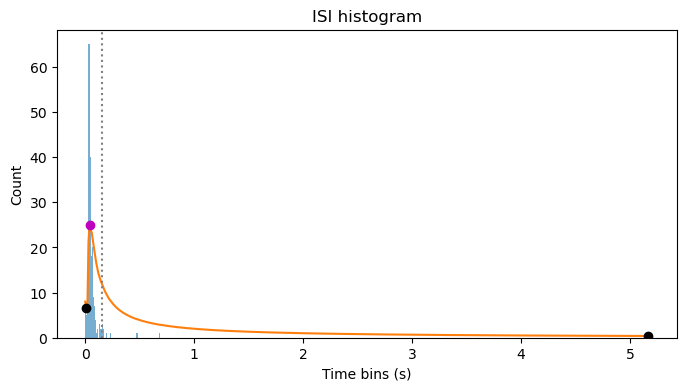

,mean_isi,median_isi,kurtosis,skewness,cma_threshold,cma_valley_time,cma_peak_time
0,0.084071,0.0431,222.864529,14.087052,0.15,5.15,0.04


In [24]:
# Assign ISI data to this variable
hist_data = spikes_table['isi_s']
 
# Empty DataFrame for histogram stats
hist_stats = pd.DataFrame()
 
# Bin size
bin_size = 10  # in miliseconds
 
# Histogram
isi_range = np.ptp(hist_data)
bins = int((isi_range * 1000 / bin_size) + 0.5)  # Round to the nearest integer
hist = np.histogram(hist_data, bins=bins)
hist_counts = hist[0]
hist_bins = hist[1]
 
# Cumulative moving average
cum = np.cumsum(hist_counts)  # Cumulative sum
cma = cum / np.arange(1, len(cum) + 1)
 
# Calculate peaks and valleys of the cma
cma_peaks_indexes = scipy.signal.argrelextrema(cma, np.greater)
cma_valleys_indexes = scipy.signal.argrelextrema(cma, np.less)
 
# Select the peak you're interested in
peak_index = cma_peaks_indexes[0][0]  # Change second number to select the peak
alpha = cma[peak_index] * 0.5  # Half-peak, adapt the value to your threshold criterion
 
# Calculate cma_threshold_index relative to the selected cma_peak
cma_threshold = (np.argmin(cma[peak_index:] >= alpha) + peak_index) * bin_size/1000
 
# Dataframe with histogram statistics
length = len(hist_stats)
hist_stats.loc[length, 'mean_isi'] = np.mean(hist_data)
hist_stats.loc[length, 'median_isi'] = np.median(hist_data)
hist_stats.loc[length, 'kurtosis'] = kurtosis(hist_counts)
hist_stats.loc[length, 'skewness'] = skew(hist_counts, bias=True)
hist_stats.loc[length, 'cma_threshold'] = cma_threshold
hist_stats.loc[length, 'cma_valley_time'] = cma_valleys_indexes[0][1] * bin_size/1000  # Change peak index as needed
hist_stats.loc[length, 'cma_peak_time'] = cma_peaks_indexes[0][0] * bin_size/1000  # Change peak index as needed
 
# Plot ISI histogram
fig, ax = plt.subplots(figsize=(8, 4))
ax.set_title("ISI histogram") 
ax.hist(hist_data, bins=bins, alpha=0.6)
 
# Plot CMA
cma_x = np.linspace(np.min(hist_bins), np.max(hist_bins), bins)
ax.plot(cma_x, cma)
 
# Plot CMA threshold line
ax.axvline(cma_threshold, linestyle="dotted", color="gray")
 
# Plot CMA valleys
ax.plot(cma_x[cma_valleys_indexes], cma[cma_valleys_indexes], 'ko')
ax.plot(cma_x[cma_peaks_indexes], cma[cma_peaks_indexes], 'mo')
 
# ax.set_xscale('log')  # Logarithmic scale may be easier to set the threshold
ax.set_xlabel("Time bins (s)")
ax.set_ylabel("Count")
 
# Show graph and table
plt.show()
hist_stats

Let's do something simpler:

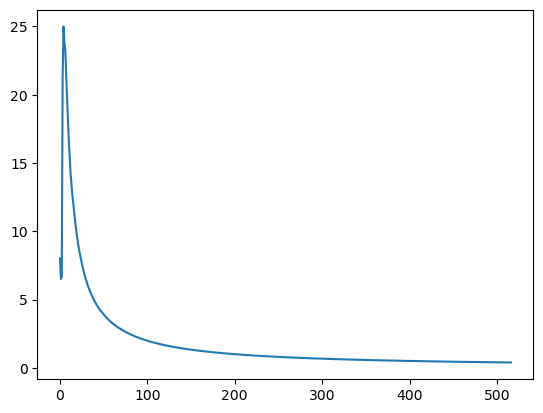

In [27]:
# Assign ISI data to this variable
hist_data = spikes_table['isi_s']
 
# Empty DataFrame for histogram stats
hist_stats = pd.DataFrame()
 
# Bin size
bin_size = 10  # in miliseconds
 
# Histogram
isi_range = np.ptp(hist_data)
bins = int((isi_range * 1000 / bin_size) + 0.5)  # Round to the nearest integer
hist = np.histogram(hist_data, bins=bins)
hist_counts = hist[0]
hist_bins = hist[1]
 
# Cumulative moving average
cum = np.cumsum(hist_counts)  # Cumulative sum
cma = cum / np.arange(1, len(cum) + 1)

plt.plot(cma)